# Lab session 2: Clustering with Python

In this session, we will explore the unsupervised learning task of clustering. The first part of this exercise will let you play around standard clustering methods on different data example. In the following part, we explore *good practices* for clustering data. The last section consists of an open-ended real-world application. 

In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import tqdm 
import pandas as pd

from course_checks import grader

# Part 1. Clustering

## Exercise 1. Spectral Clustering from scratch
The goal is to implement Spectral Clustering as described in Luxburg's tutorial: https://people.csail.mit.edu/dsontag/courses/ml14/notes/Luxburg07_tutorial_spectral_clustering.pdf. We will start with implementing different part of the algorithm and work towards the standard object-oriented language used in `sklearn`. 


### Question 1. Similarity graph
Implement a function that constructs the similarity graph $S \in \mathbb{R}^{N \times N}$ for a given set of points $x_1, \cdots, x_n$ based on the three criteria:
1) $\epsilon$-neighborhood graph: $S_{i,j} = 1$ if $||x_i - x_j||_2 \leq \epsilon$, $S_{i,j} = 0$ otherwise.
2) $k$-nearest neighbor graph: $S_{i,j} = 1$ if $i$ is among the $k$ nearest neighbors of $j$. $S_{i,j} = 0$ otherwise.
3) fully connected graph with weighted distance: $S_{i,j} = \exp(-||x_i-x_j||^2/(2\sigma^2))$

The suggested roadmap is to break it down into 3 standalone functions that will be called by `compute_similarity`.

In [ ]:
from scipy.spatial.distance import pdist, squareform

def epsilon_neighbor(X, eps=1.0):
    # TODO: Compute the quantity for epsilon neighborhood graph
    raise NotImplementedError("Complete epsilon_neighbor")

In [ ]:
from scipy.spatial.distance import pdist, squareform 
 
def epsilon_neighbor(X, eps=1.0):
    N = X.shape[0]
    D = squareform(pdist(X, 'sqeuclidean'))
    S = 1.0 * (D <= eps)
    np.fill_diagonal(S, 0)
    return S

In [ ]:
def k_nearest_neighbor(X, n_neighbors=5):
    # TODO: Compute the quantity for k nearest neighbor graph
    raise NotImplementedError("Complete k_nearest_neighbor")

In [ ]:
from sklearn.neighbors import NearestNeighbors
def k_nearest_neighbor(X, n_neighbors=5):
    N = X.shape[0]
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean').fit(X)
    D, mask = nn.kneighbors(X)
    S = np.zeros((N, N))
    S[mask] = 1
    np.fill_diagonal(S, 0)
    return S

In [ ]:
def gaussian_kernel_neighbor(X, sigma=1):
    # TODO: Compute the quantity for the fully connected graph with gaussian kernel weights
    raise NotImplementedError("Complete gaussian_kernel_neighbor")

In [124]:
def gaussian_kernel_neighbor(X, sigma=1):
    D = squareform(pdist(X, 'sqeuclidean'))
    S = np.exp(-D/(2*sigma**2))
    np.fill_diagonal(S, 0)
    return S

In [ ]:
def compute_similarity(X, graph='epsilon', n_neighbors=5, eps=1.0, sigma=1):
    # TODO: Fill in the function that returns the correct similarity graph
    raise NotImplementedError("Complete compute_similarity")

In [131]:
def compute_similarity(X, graph='epsilon', n_neighbors=5, eps=1.0, sigma=1):
    if graph=='epsilon':
        return epsilon_neighbor(X, eps=eps)
    elif graph=='knn':
        return k_nearest_neighbor(X, n_neighbors=n_neighbors)
    elif graph=='gaussian':
        return gaussian_kernel_neighbor(X, sigma=sigma)

In [103]:
# Verify your solutions here: 
grader.check("epsilon_neighbor", epsilon_neighbor)
grader.check("k_nearest_neighbor", k_nearest_neighbor)
grader.check("gaussian_kernel_neighbor", gaussian_kernel_neighbor)
grader.check("compute_similarity", compute_similarity)


NameError: name 'grader' is not defined

### Question 2. Graph Laplacian

Spectral Clustering requires to compute the graph Laplacian. The paper linked earlier details different strategies. We will focus on the *unnormalized graph Laplacian* defined as $L = D-W$ where $D$ is the degree matrix, and $W$ is the weighted adjacency matrix. In practice, $W$ is a transformation of $S$ that enforces stronger local connectedness. For a simplified version, we will take $W := S$. Then the degree matrix $D$ is defined as the diagonal matrix such that $D_{i,i}=\sum_j W_{i,j}$. 


In [104]:
def graph_laplacian(S):
    # TODO: Compute L = D - S
    raise NotImplementedError("Complete graph_laplacian")


In [105]:
def graph_laplacian(S):
    D = np.diag(np.sum(S, axis=1))
    L = D - S
    return L

In [ ]:
# Verify your solutions here: 
grader.check("graph_laplacian", graph_laplacian)

### Question 3. Eigenvectors 

Now that you have the graph Laplacian $L$, write a function that returns the $k$ first eigenvectors of $L$. 

In [ ]:
from scipy.linalg import eigh 
def get_eigenvectors(L, k=5):
    # TODO: Compute U = [u_1, ..., u_k] with L u_i = a_i * u_i with a_1 =< a_2 ... =< a_n
    raise NotImplementedError("Complete get_eigenvectors")

In [106]:
from scipy.linalg import eigh 
def get_eigenvectors(L, k=5):
    vals, vecs = eigh(L)
    U = vecs[:, :k]
    return U

### Question 4. Spectral Clustering

We are about to wrap up writing the Spectral Clustering algorithm. Now it remains to cluster using KMeans clustering on the rows of $U \in \mathbb{R}^{N \times k}$ into clusters $C_1, \cdots, C_k$. 

In [ ]:
from sklearn.cluster import KMeans

def spectral_clustering(X, n_clusters=3, graph = 'gaussian', eps=1.0, sigma=1.0, n_neighbors=5):
    S = compute_similarity(X, graph=graph, n_neighbors=n_neighbors, eps=eps, sigma=sigma)
    L = graph_laplacian(S)
    U = get_eigenvectors(L, k=n_clusters)
    # TODO: Fill in this section to complete spectral clustering
    raise NotImplementedError("Complete spectral_clustering") 

In [142]:
from sklearn.cluster import KMeans

def spectral_clustering(X, n_clusters=3, graph = 'gaussian', eps=1.0, sigma=1.0, n_neighbors=5):
    S = compute_similarity(X, graph=graph, n_neighbors=n_neighbors, eps=eps, sigma=sigma)
    L = graph_laplacian(S)
    U = get_eigenvectors(L, k=n_clusters)
    km = KMeans(n_clusters=n_clusters)
    km.fit(U)
    return km

### Question 5. Toy dataset
Let's apply our version vs the typical `sklearn` implementation on a toy dataset. Compare the clustering assignments obtained with `KMeans`, `SpectralClustering` and your version.

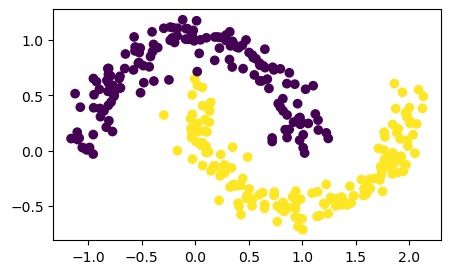

In [108]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.1)
plt.figure(figsize=(5,3))
plt.scatter(X[:,0], X[:,1], c=y)

In [ ]:
from sklearn.cluster import KMeans, SpectralClustering
# TODO: Compare your implementation with Spectral Clustering from sklearn, and compare with KMeans. 


In [164]:
sp = spectral_clustering(X, n_clusters=2, graph='gaussian', sigma=0.1)
sklearn_labels = SpectralClustering(n_clusters=2).fit_predict(X)
km_labels = KMeans(n_clusters=2).fit_predict(X)

In [ ]:
# TODO: plot the data colored by clustering solutions

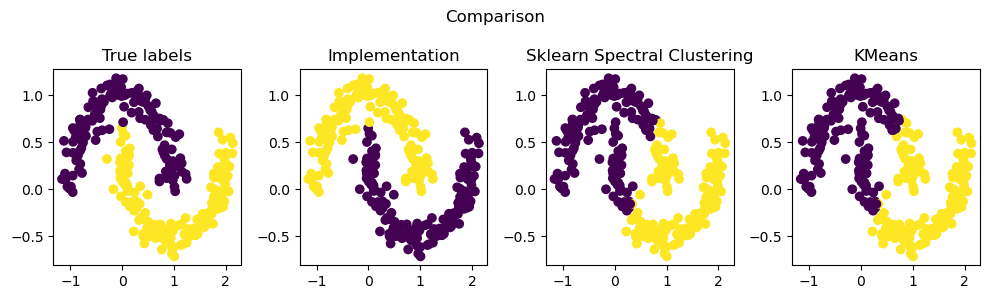

In [171]:
fig, ax = plt.subplots(1, 4, figsize=(10,3))
ax[0].scatter(X[:,0], X[:,1], c=y)
ax[0].set_title("True labels")
ax[1].scatter(X[:,0], X[:,1], c=sp.labels_)
ax[1].set_title("Implementation")
ax[2].scatter(X[:,0], X[:,1], c=sklearn_labels)
ax[2].set_title("Sklearn Spectral Clustering")
ax[3].scatter(X[:,0], X[:,1], c=km_labels)
ax[3].set_title("KMeans")
fig.suptitle("Comparison")
fig.tight_layout()
plt.show()

# Part 2. Model selection for clustering

## Exercise 2. Standard clustering algorithms

In this short exercise, you will be applying standard clustering algorithms from the `scikit-learn` package on toy datasets. 

### Question 1. Simulating data
Let $\pi = [0.2, 0.5, 0.3]$. Set $N=1000$ across all 4 datasets.
* Simulate a gaussian mixture with 3 components and two features as follows: 
    - $y \sim \text{Mult}(\pi, 1)$ and $X \ |\ y=k \sim N(\mu_k, \sigma_k^2 I_2)$ for $k \in \{1, 2, 3\}$ 
    - with $\mu_1 = [-3, 3], \ \mu_3 = [3, -3]$ and $\mu_2 = [3, 0]$, $\sigma_1 = 1.5, \sigma_2 = 1.0, \sigma_3=0.5$. 
* Simulate a Poisson lognormal mixture with 3 components and 2 features as follows: 
    - $z_k = z | \ y=k \sim N(\mu_k, \sigma_k^2 I_2)$ and $X \ | \ z_k \sim \mathcal{P}(\exp(z_k))$, 
    - with all the same parameters as the gaussian mixture for $z$ as before.
* Use `sklearn.datasets.make_moons` to generate the interlaced moon dataset. 
* Sample from three uniform distributions: $X\ | \ y=k \sim \text{Unif}(r_k)$ with $r_1 = [[-1, -0.5],[-0.5, 1]]$, $r_2 = [[-0.1, 0.2],[0.8, 1]]$ and $r_3 = [[0.3, -1], [0.7,-0.2]]$.

In [103]:
from sklearn.datasets import make_moons 
from scipy.stats import poisson 

dataset_dict = {}

rng = np.random.default_rng(123)
N, n_clusters = 1000, 3
X = np.zeros((N, 2))

mu_1, mu_2, mu_3 = np.array([-3, 3]), np.array([3, -3]), np.array([3, 0])
mu = np.array([mu_1, mu_2, mu_3])
sigma_list = np.array([1.5, 1, 0.5])
pi = [0.2, 0.5, 0.3]
r_1, r_2, r_3 = np.array([[-1, -0.5],[-0.5, 1]]), np.array([[-0.1, 0.2],[0.8, 1]]), np.array([[0.3, -1], [0.7,-0.2]])
r = np.array([r_1, r_2, r_3])
data_dict = {}

# Gaussian data
y = rng.choice(n_clusters, p=pi, size=(N,))
for k in range(n_clusters):
    X[y==k, :] = rng.multivariate_normal(mean=mu[k], cov = sigma_list[k]**2 * np.eye(2), size=sum(1*(y==k)))
dataset_dict['GMM'] = {'data': X, 'label': y}

# Poisson lognormal mixture
y = rng.choice(n_clusters, p=pi, size=(N,))
z = np.zeros((N, 2))
for k in range(n_clusters):
    z[y==k, :] = rng.multivariate_normal(mean=mu[k], cov = sigma_list[k]**2 * np.eye(2), size=sum(1*(y==k)))
X = poisson.rvs(np.exp(z), random_state=rng)
dataset_dict['PLN'] = {'data': X, 'label': y}

# Moons 
X, y = make_moons(n_samples=N, noise=0.1)
dataset_dict['moons'] = {'data':X, 'label': y}

# Uniform distributions
X = np.zeros((N, 2))
y = rng.choice(n_clusters, p=pi, size=(N,))
for k in range(n_clusters):
    X[y==k, :] = rng.uniform(low=r[k, 0], high=r[k, 1], size=(sum(1*(y==k)), 2))
dataset_dict['uniform'] = {'data': X, 'label': y}

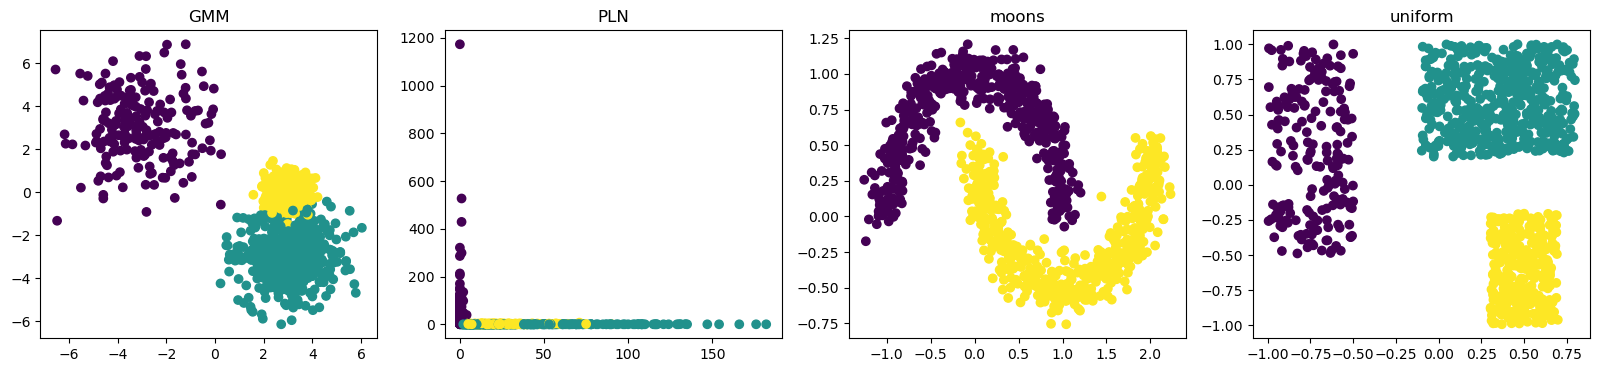

In [104]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for i, data in enumerate(dataset_dict):
    ax[i].scatter(dataset_dict[data]['data'][:, 0],dataset_dict[data]['data'][:, 1], c=dataset_dict[data]['label'])
    ax[i].set_title(data)

### Question 2. Applying clustering algorithms

Read this page: https://scikit-learn.org/stable/modules/clustering.html. Apply 4 of the standard clustering algorithms to the 4 datasets. Carefully check the hyperparameters of your chosen methods. In a 4 by 5 plot, show the data colored by the predicted labels for each dataset and each clustering method. The first column should contain the data colored with its original labels. 

In [ ]:
from sklearn. ... import ... 
# TODO

/Users/clairehe/anaconda3/envs/claire/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/clairehe/anaconda3/envs/claire/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 728 with accuracies 
[5.29836683e-15 8.64812344e-06 2.86113371e-05 1.48832821e-05]
not reaching the requested tolerance 1.4901161193847656e-05.
Use iteration 613 instead with accuracy 
1.0021352797806378e-05.

  _, diffusion_map = lobpcg(
/Users/clairehe/anaconda3/envs/claire/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[3.68915164e-15 7.33003532e-06 9.80175763e-06 2.29536182e-05]
not reaching the requested tolerance 1.4901161193847656e-05.
  _, diffusion_map = lobpcg(
/Users/clairehe/anaconda3/envs/claire/lib/python3.10/site-packages/sklearn/base.py:

Text(0.5, 1.0, 'DBSCAN Clustering')

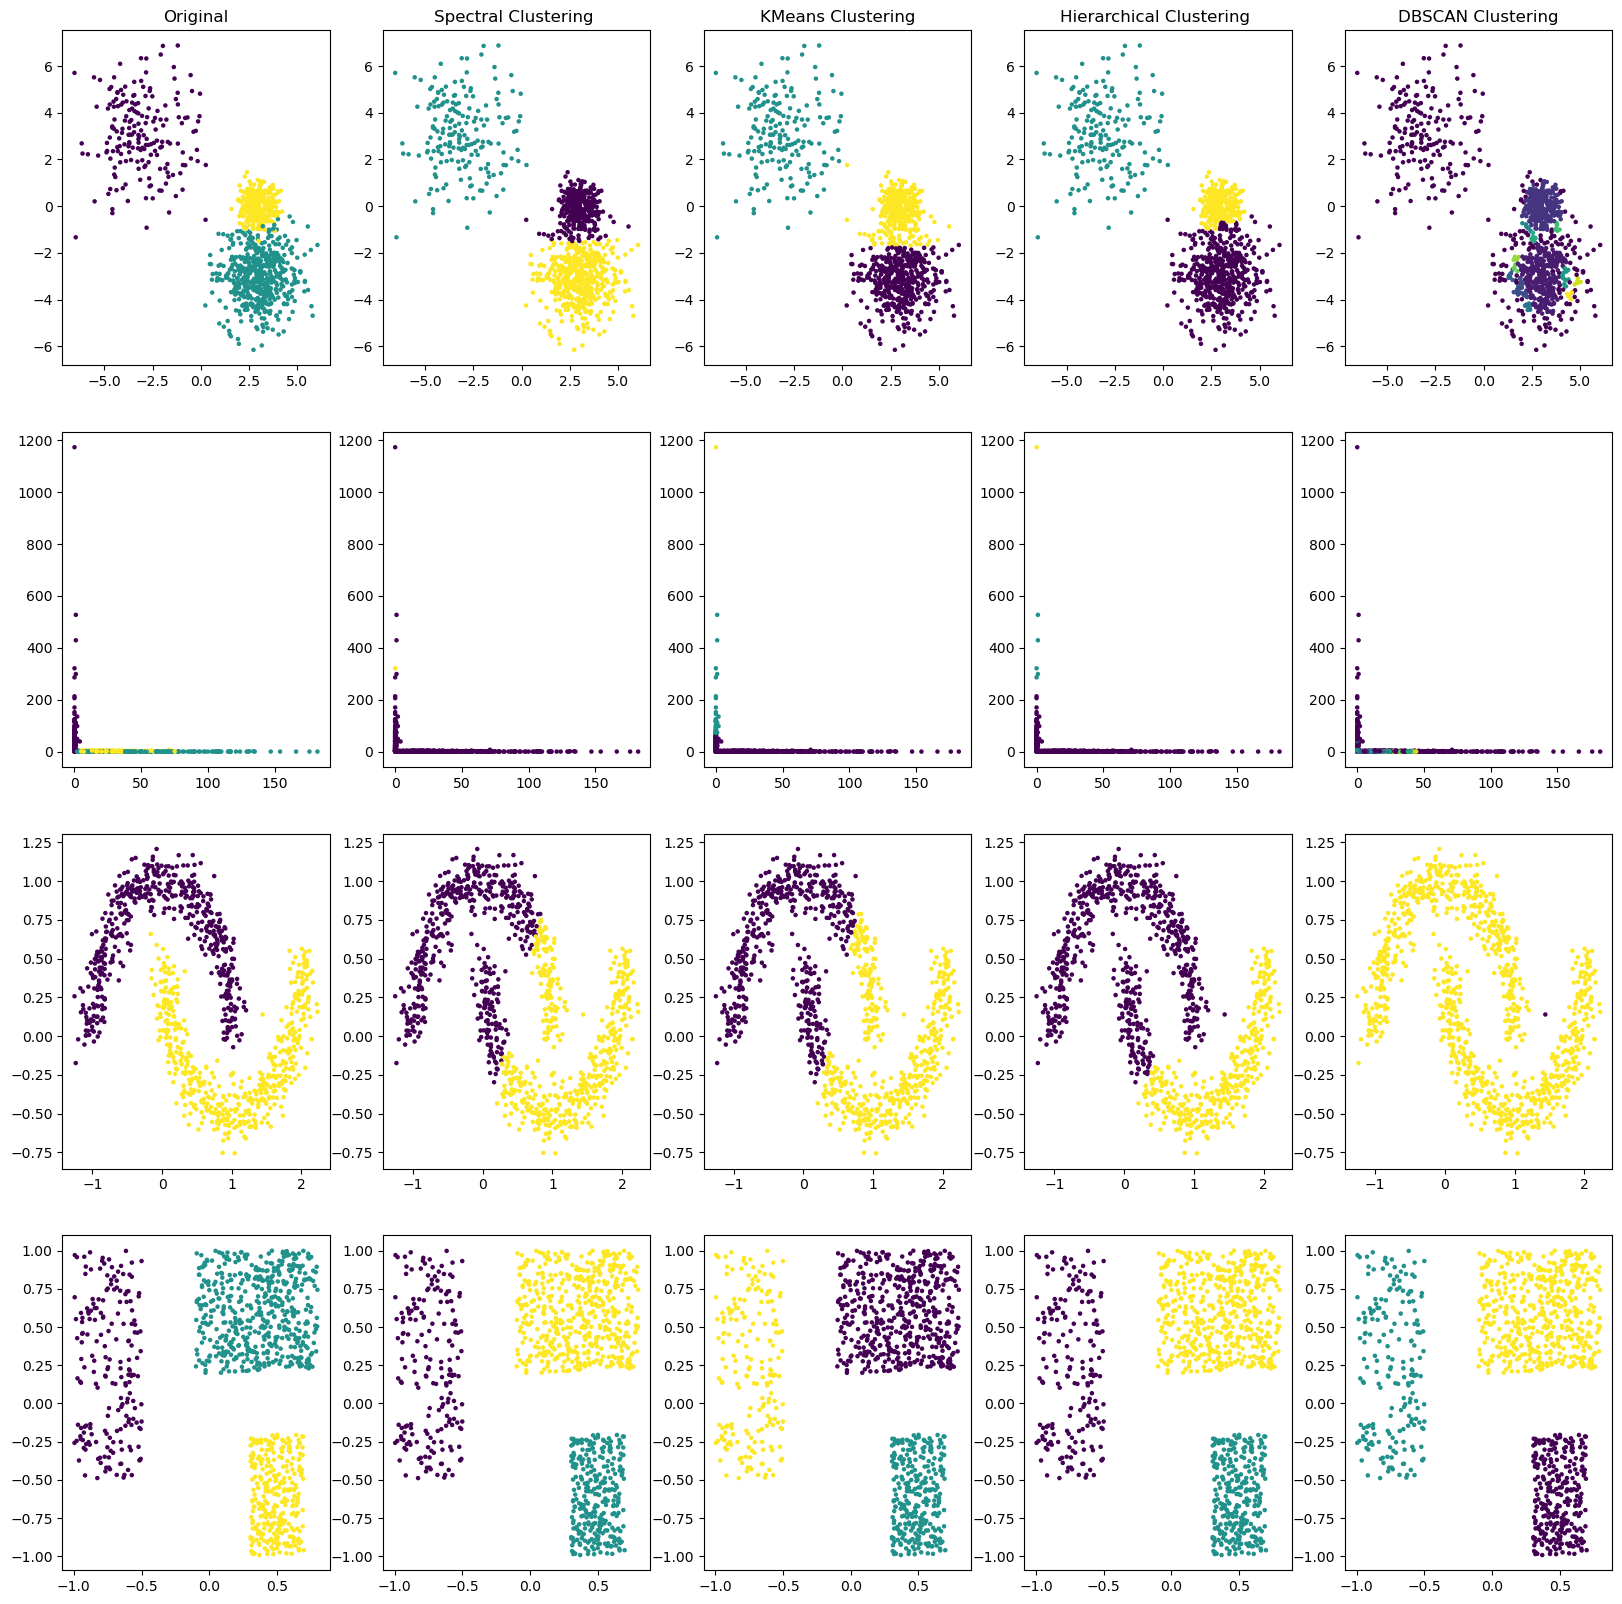

In [112]:
from sklearn.cluster import SpectralClustering, KMeans, AgglomerativeClustering, DBSCAN
cluster_number = [3, 3, 2, 3]
fig, ax = plt.subplots(4, 5, figsize=(20,20))
for i, data in enumerate(dataset_dict):
    K = cluster_number[i]
    X, y = dataset_dict[data]['data'], dataset_dict[data]['label']
    sp_labels = SpectralClustering(n_clusters=K).fit_predict(X)
    km_labels = KMeans(n_clusters=K).fit_predict(X)
    hc_labels = AgglomerativeClustering(n_clusters=K).fit_predict(X)
    db_labels = DBSCAN(eps=0.2).fit_predict(X)

    ax[i, 0].scatter(X[:, 0], X[:, 1], c=y, s=5)
    ax[i, 1].scatter(X[:, 0], X[:, 1], c=sp_labels, s=5)
    ax[i, 2].scatter(X[:, 0], X[:, 1], c=km_labels, s=5)
    ax[i, 3].scatter(X[:, 0], X[:, 1], c=hc_labels, s=5)
    ax[i, 4].scatter(X[:, 0], X[:, 1], c=db_labels, s=5)
    
ax[0, 0].set_title("Original")
ax[0, 1].set_title("Spectral Clustering ")
ax[0, 2].set_title("KMeans Clustering")
ax[0, 3].set_title("Hierarchical Clustering ")
ax[0, 4].set_title("DBSCAN Clustering")

### Question 3. Choosing $K$, model selection and validation
How does one decide which method to choose and what hyperparameters? 